This notebook shows a clear workflow for the GVZ index.The work has six main steps：
Step one prepares the data and checks its quality.
Step two looks at the trend and monthly change of the GVZ index.
Step three builds a model with four kinds of basis functions.
Step four tests the models and picks the best one.
Step five uses the best model to forecast the next three months.
Step six gives the final results and saves all figures and tables.

Section 1: Introduction and Data Preparation
This section explains how the data is prepared for the study. The file is loaded and its structure and type are checked to make sure it is correct. Missing values are removed to avoid errors. Columns are changed to the right format so they can be used in the model. The Month Index is checked to make sure it covers the range from one to two hundred and eight. These steps make the data clean and ready for the analysis.

In [199]:
!pip install scikit-learn
# Import the required libraries
import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

# Set seed, hide warnings and create folder
np.random.seed(42)
warnings.filterwarnings("ignore")
os.makedirs("outputs", exist_ok=True)

# Set plot style
plt.rcParams["figure.figsize"] = (8, 5)
plt.rcParams["axes.grid"] = True

# Declare MSE function
def mse(y_true: np.ndarray, y_pred: np.ndarray) -> float:
    """Return mean squared error as float."""
    return float(mean_squared_error(y_true, y_pred))


In [200]:
# Load the GVZ dataset
df = pd.read_csv("GVZ.csv")

# Check if the necessary columns are present
assert {"Month Index", "GVZ"}.issubset(df.columns), f"Unexpected columns: {df.columns.tolist()}"

# Receive data in an array format
x_all = df["Month Index"].astype(float).to_numpy()
y_all = df["GVZ"].astype(float).to_numpy()

# Check the appropriate index range
assert int(x_all.min()) <= 1 and int(x_all.max()) >= 208, "Month Index range should cover 1..208"

# Display the shape and first rows
print(df.shape)
display(df.head())

(4362, 3)


,Year-Month,Month Index,GVZ
0,2008-6,1,22.89
1,2008-6,1,22.69
2,2008-6,1,22.78
3,2008-6,1,23.60
4,2008-6,1,24.47


In [201]:
# Eliminate rows that are missing GVZ and Month Index
df = df.dropna(subset=["GVZ", "Month Index"])

# Convert to numeric types
df["GVZ"] = pd.to_numeric(df["GVZ"], errors="coerce")
df["Month Index"] = pd.to_numeric(df["Month Index"], errors="coerce")

# Drop any NA remaining after conversion
df = df.dropna(subset=["GVZ", "Month Index"])

# Check the index range
assert int(df["Month Index"].min()) <= 1 and int(df["Month Index"].max()) >= 208, \
    "Month Index must cover 1..208"

# Display summary
print(f"Final dataset shape: {df.shape}")
print(df.describe())


Final dataset shape: (4362, 3)
       Month Index          GVZ
count  4362.000000  4362.000000
mean    104.458505    18.524821
std      60.023364     6.786933
min       1.000000     8.880000
25%      52.000000    14.730000
50%     104.000000    17.165000
75%     156.000000    20.517500
max     208.000000    64.530000


Section 2: Data Description and Visualization
This section shows the overall pattern of the GVZ index over time. A raw daily scatter gives the first look at the data and helps to see the basic shape. Monthly mean values are then calculated to make the trend clear and easy to read. A line plot is used to show how the index moves over time. A shaded band highlights one standard deviation above and below the mean and gives a sense of the volatility. Key peak and trough events are added to give context and support the understanding of the pattern.

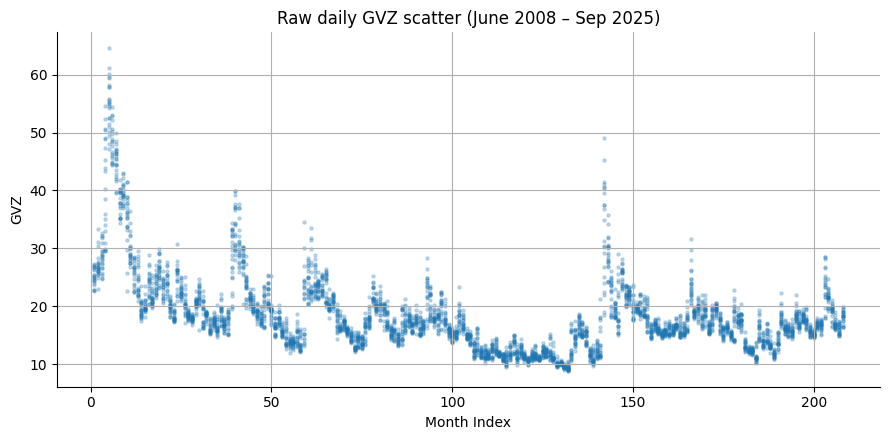

Saved: outputs/fig_raw_scatter.png


In [202]:
# Raw scatter plot comparing GVZ and Month Index
plt.figure(figsize=(9, 4.5))
plt.scatter(x_all, y_all, s=5, alpha=0.25)
plt.title("Raw daily GVZ scatter (June 2008 – Sep 2025)")
plt.xlabel("Month Index")
plt.ylabel("GVZ")

# Drop top and right borders
ax = plt.gca()
for spine in ["top", "right"]:
    ax.spines[spine].set_visible(False)

# Save and display plot
plt.tight_layout()
plt.savefig("outputs/fig_raw_scatter.png", dpi=300, bbox_inches="tight")
plt.show()
print("Saved: outputs/fig_raw_scatter.png")

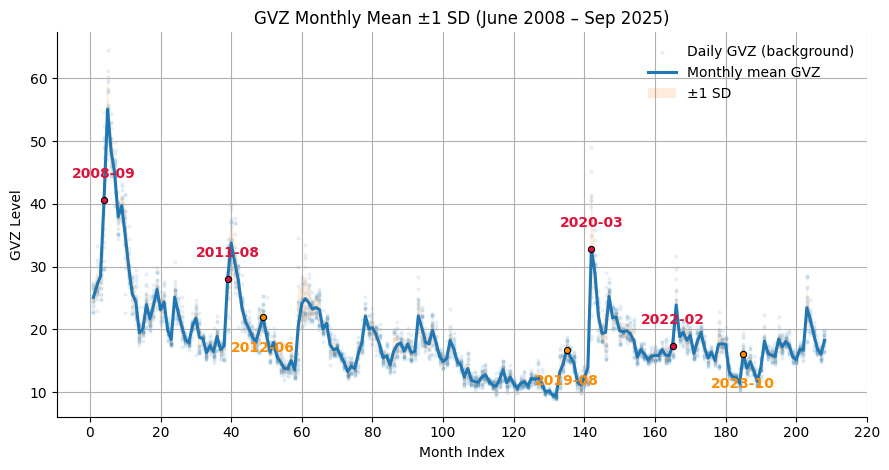

In [203]:
# Group by month and compute stats
g = df.groupby("Month Index")["GVZ"]
monthly = pd.DataFrame({
    "mean": g.mean(),
    "std": g.std(),
    "median": g.median(),
    "q25": g.quantile(0.25),
    "q75": g.quantile(0.75)
}).reset_index()

# Extract monthly arrays
x_mon = monthly["Month Index"].to_numpy()
m = monthly["mean"].to_numpy()
sd = monthly["std"].to_numpy()

# Set up figure
plt.figure(figsize=(9, 4.8))

# Scatter daily values for background
plt.scatter(x_all, y_all, s=4, alpha=0.08, label="Daily GVZ (background)")

# Plot monthly mean line
plt.plot(x_mon, m, linewidth=2.2, label="Monthly mean GVZ")

# Shade ±1 SD
plt.fill_between(x_mon, m - sd, m + sd, alpha=0.15, label="±1 SD")

# Base month for indexing
BASE = pd.Timestamp("2008-06-01")

# Convert YYYY-MM to month index
def ym_to_index(ym_str: str) -> int:
    """'YYYY-MM' -> Month Index (2008-06 => 1)."""
    dt = pd.to_datetime(ym_str + "-01")
    months = (dt.year - BASE.year) * 12 + (dt.month - BASE.month)
    return int(months + 1)

# Get y at a given month index
def pick_y(idx: int, x_arr: np.ndarray, y_arr: np.ndarray) -> float:
    """Return y for exact index; None if missing."""
    pos = np.where(x_arr == idx)[0]
    if len(pos) == 0:
        return None
    return float(y_arr[pos[0]])

# Key peak months
key_ym_list_peak = [
    "2008-09",  # Global Financial Crisis peak
    "2011-08",  # Eurozone debt crisis
    "2020-03",  # COVID-19 onset
    "2022-02",  # Russia-Ukraine conflict
]

# Key trough months
key_ym_list_trough = [
    "2012-06",  # Post-GFC stabilization
    "2019-08",  # Pre-COVID low volatility
    "2023-10",  # Post-pandemic stability
]

# Styles for markers/labels
peak_color = "crimson"        # peak points
trough_color = "darkorange"   # trough points
dot_size = 20
label_off_up = 3.5
label_off_dn = 3.8

# Plot peaks with labels
for ym in key_ym_list_peak:
    idx = ym_to_index(ym)
    yv = pick_y(idx, x_mon, m)
    if yv is None:
        continue
    plt.scatter(idx, yv, s=dot_size, color=peak_color,
                edgecolors="black", linewidths=0.8, zorder=6)
    plt.text(idx, yv + label_off_up, ym, ha="center",
             fontsize=10, fontweight="bold", color=peak_color, zorder=7)

# Plot troughs with labels
for ym in key_ym_list_trough:
    idx = ym_to_index(ym)
    yv = pick_y(idx, x_mon, m)
    if yv is None:
        continue
    plt.scatter(idx, yv, s=dot_size, color=trough_color,
                edgecolors="black", linewidths=0.8, zorder=6)
    plt.text(idx, yv - label_off_dn, ym, ha="center", va="top",
             fontsize=10, fontweight="bold", color=trough_color, zorder=7)

# X ticks every 20 months
plt.xticks(np.arange(0, 221, 20))

# Clean frame
ax = plt.gca()
for spine in ["top", "right"]:
    ax.spines[spine].set_visible(False)

# Titles and labels
plt.title("GVZ Monthly Mean ±1 SD (June 2008 – Sep 2025)")
plt.xlabel("Month Index")
plt.ylabel("GVZ Level")

# Legend
plt.legend(loc="upper right", frameon=False)

# Save and display
plt.tight_layout()
plt.savefig("outputs/fig_overview_final.png", dpi=300, bbox_inches="tight")
plt.show()


Section 3: Basis Functions and Model Fitting
This section builds the Least Squares Basis Function model. Four basis families are used in the study. They are Piecewise Constant Piecewise Linear Radial and Laplace. The number of components k is the only hyperparameter that is changed during the process. Other width settings stay the same to make the comparison fair. A design matrix is created for each basis family so the model can be trained and tested in a clear and structured way.

In [204]:
# Split data into train, val and test sets
def split_tvt(x: np.ndarray, y: np.ndarray):
    """Return (x_tr,y_tr,x_val,y_val,x_te,y_te) by assignment spec."""
    train_mask = (x >= 1) & (x <= 150)    # training range
    val_mask   = (x >= 151) & (x <= 180)  # validation range
    test_mask  = (x >= 181) & (x <= 208)  # test range

    return (x[train_mask], y[train_mask],
            x[val_mask],   y[val_mask],
            x[test_mask],  y[test_mask])

# Apply split
x_tr, y_tr, x_val, y_val, x_te, y_te = split_tvt(x_all, y_all)

# Print split ranges
print(f"Train: {x_tr.min():.0f}-{x_tr.max():.0f} | "
      f"Val: {x_val.min():.0f}-{x_val.max():.0f} | "
      f"Test: {x_te.min():.0f}-{x_te.max():.0f}")

Train: 1-150 | Val: 151-180 | Test: 181-208


In [205]:
# Get k breakpoints between min and max
def breakpoints(x: np.ndarray, k: int):
    """ti = xmin + i*(xmax - xmin)/(k+1), i=1..k"""
    x_min, x_max = float(np.min(x)), float(np.max(x))
    return [x_min + i * (x_max - x_min) / (k + 1) for i in range(1, k + 1)]

# Piece-wise constant model
def design_mat_pwc(x: np.ndarray, k: int) -> np.ndarray:
    """[1, I(x>t1), ..., I(x>tk)]"""
    x = np.asarray(x).reshape(-1)
    Phi = np.ones((len(x), 1))
    for t in breakpoints(x, k):
        Phi = np.hstack([Phi, (x > t).astype(float).reshape(-1, 1)])
    return Phi

# Piece-wise linear model
def design_mat_pwl(x: np.ndarray, k: int) -> np.ndarray:
    """[1, x, (x-t1)I(x>t1), ..., (x-tk)I(x>tk)]"""
    x = np.asarray(x).reshape(-1)
    Phi = np.hstack([np.ones((len(x), 1)), x.reshape(-1, 1)])
    for t in breakpoints(x, k):
        Phi = np.hstack([Phi, ((x - t) * (x > t)).astype(float).reshape(-1, 1)])
    return Phi

# Radial in Gaussian-like format
def design_mat_radial(x: np.ndarray, k: int) -> np.ndarray:
    """[1, exp(-(x-ti)^2/8), ...]"""
    x = np.asarray(x).reshape(-1)
    Phi = np.ones((len(x), 1))
    for t in breakpoints(x, k):
        Phi = np.hstack([Phi, np.exp(-((x - t) ** 2) / 8.0).reshape(-1, 1)])
    return Phi

# Laplace basis
def design_mat_laplace(x: np.ndarray, k: int) -> np.ndarray:
    """[1, exp(-|x-ti|/8), ...]"""
    x = np.asarray(x).reshape(-1)
    Phi = np.ones((len(x), 1))
    for t in breakpoints(x, k):
        Phi = np.hstack([Phi, np.exp(-np.abs(x - t) / 8.0).reshape(-1, 1)])
    return Phi

# Dictionary to select design functions
DESIGNERS = {
    "pwc": design_mat_pwc,
    "pwl": design_mat_pwl,
    "radial": design_mat_radial,
    "laplace": design_mat_laplace,
}

In [206]:
# Fit linear model and make predictions
def fit_and_predict(Phi_train: np.ndarray, y_train: np.ndarray,
                    Phi_new: np.ndarray):
    """Fit LinearRegression(fit_intercept=False) then predict on Phi_new."""
    lr = LinearRegression(fit_intercept=False)  
    lr.fit(Phi_train, y_train)                  
    return lr.predict(Phi_new), lr              



Section 4: Validation Search and Model Selection
This section searches over different values of k on the validation set. The main goal is to find the value that gives the smallest validation mean squared error. The search is done for all four basis families in the same way. The best k for each family is written in a table so it is clear which model performs best.

In [207]:
# Find the best K
def select_k(basis: str, x_tr, y_tr, x_val, y_val, k_grid=range(1, 31)):
    """Grid search k by validation MSE for a given basis family."""
    make_Phi = DESIGNERS[basis]  
    recs = []
    for k in k_grid:
        Phi_tr  = make_Phi(x_tr, k)           
        Phi_val = make_Phi(x_val, k)            
        yhat_val, _ = fit_and_predict(Phi_tr, y_tr, Phi_val)  
        recs.append({"Basis": basis, "k": k, "Validation MSE": mse(y_val, yhat_val)})
    df_rec = pd.DataFrame(recs)                 
    best_row = df_rec.loc[df_rec["Validation MSE"].idxmin()]  
    return int(best_row["k"]), float(best_row["Validation MSE"]), df_rec

# Run selection for each model
best = {}
rows_k = []
for basis in ["pwc", "pwl", "radial", "laplace"]:
    k_star, val_mse_star, _ = select_k(basis, x_tr, y_tr, x_val, y_val)
    best[basis] = {"k": k_star, "val_mse": val_mse_star}
    rows_k.append({"Basis": basis, "Best k": k_star, "Validation MSE": val_mse_star})

# Save results table
tbl_best_k = pd.DataFrame(rows_k).sort_values("Basis").reset_index(drop=True)
display(tbl_best_k)
tbl_best_k.to_csv("outputs/selected_hyperparams.csv", index=False)
print("Saved: outputs/selected_hyperparams.csv")

,Basis,Best k,Validation MSE
0,laplace,1,7.048985
1,pwc,1,24.750505
2,pwl,15,16.399450
3,radial,2,7.652779


Saved: outputs/selected_hyperparams.csv


Section 5: Test Evaluation and Comparative Plots
This section evaluates the models on the test set from index 181 to 208. The observed monthly mean values are compared with the predicted values from each model. The test mean squared error is reported for every basis family so the performance can be seen clearly. The same axes are used for all plots to make the visual comparison fair and easy to read.

In [208]:
# Model evaluation
def eval_on_test(basis: str, k_star: int, x_tr, y_tr, x_te, y_te):
    """Fit on train with best k, evaluate on test; return (test_mse, yhat_te, model)."""
    make_Phi = DESIGNERS[basis]              # pick design function
    Phi_tr = make_Phi(x_tr, k_star)          # train design matrix
    Phi_te = make_Phi(x_te, k_star)          # test design matrix
    yhat_te, model = fit_and_predict(Phi_tr, y_tr, Phi_te)  # predict
    return mse(y_te, yhat_te), yhat_te, model

# Evaluate each model
rows_test, pred_curves = [], {}
for basis in ["pwc", "pwl", "radial", "laplace"]:
    k_star = best[basis]["k"]
    test_mse, yhat_te, model = eval_on_test(basis, k_star, x_tr, y_tr, x_te, y_te)
    best[basis]["test_mse"] = test_mse
    pred_curves[basis] = yhat_te
    rows_test.append({"Basis": basis, "Best k": k_star, "Test MSE": test_mse})

# Save the results table
tbl_test = pd.DataFrame(rows_test).sort_values("Test MSE").reset_index(drop=True)
display(tbl_test)
tbl_test.to_csv("outputs/test_mse.csv", index=False)
print("Saved: outputs/test_mse.csv")

,Basis,Best k,Test MSE
0,laplace,1,12.932375
1,radial,2,15.578866
2,pwc,1,43.850529
3,pwl,15,43.883891


Saved: outputs/test_mse.csv


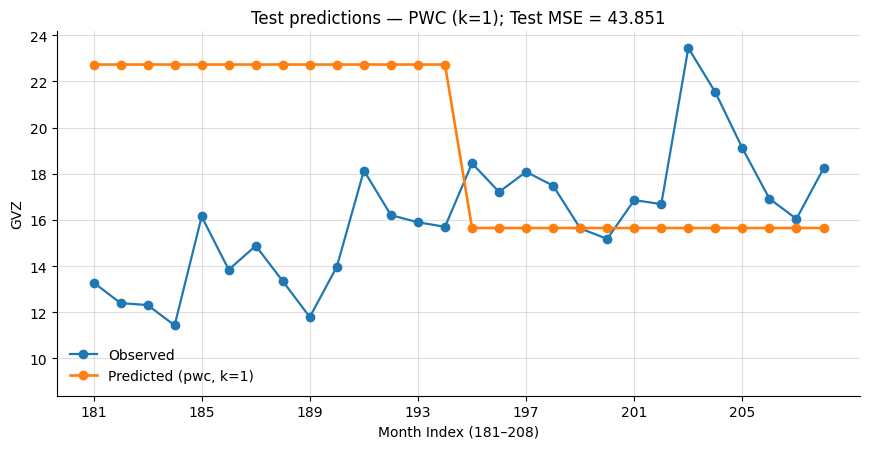

Saved: outputs/test_pred_monthly_pwc.png


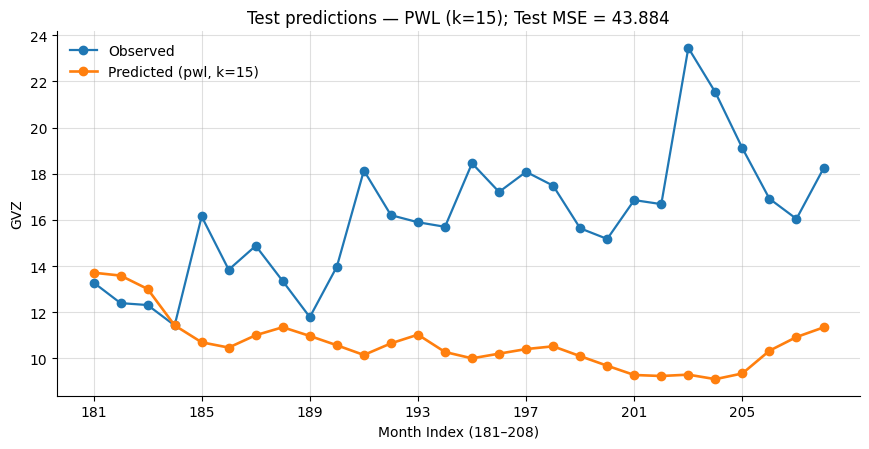

Saved: outputs/test_pred_monthly_pwl.png


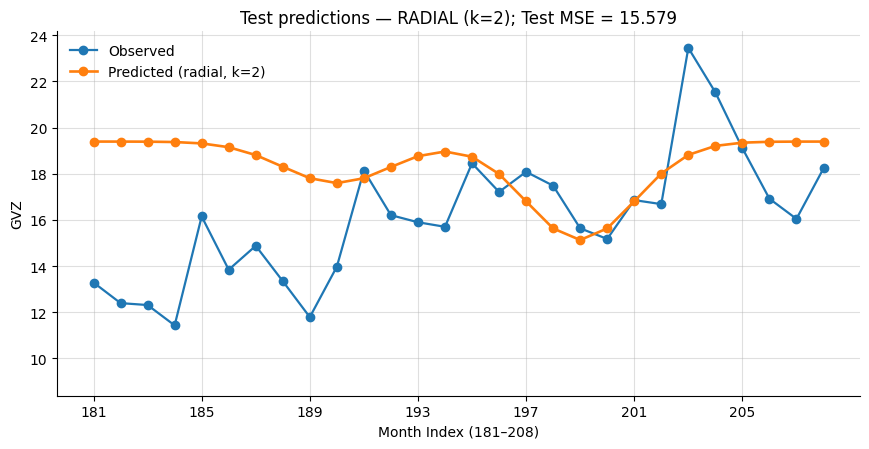

Saved: outputs/test_pred_monthly_radial.png


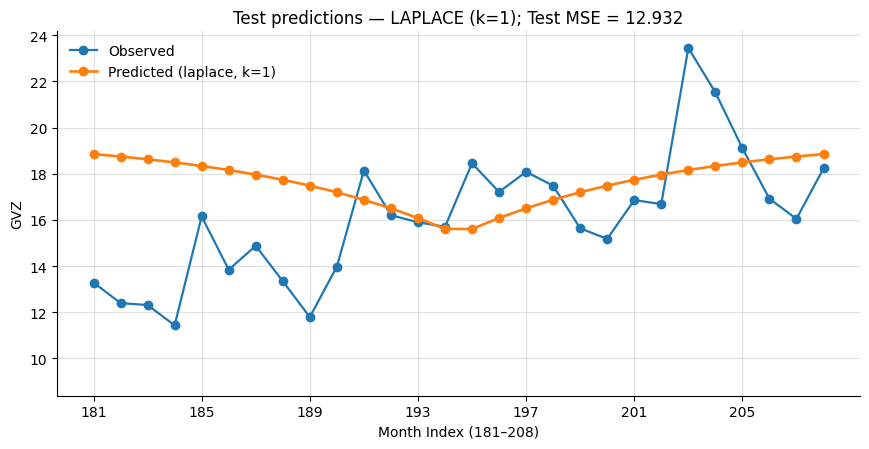

Saved: outputs/test_pred_monthly_laplace.png


In [209]:
# Monthly observation for mean
test_tbl = pd.DataFrame({"Month Index": x_te, "obs": y_te})
obs_month = test_tbl.groupby("Month Index", as_index=False)["obs"].mean()

# Monthly prediction for mean + common y-limits
pred_monthly = {}
ymin = float(obs_month["obs"].min())
ymax = float(obs_month["obs"].max())

for basis in ["pwc", "pwl", "radial", "laplace"]:
    pm = (
        pd.DataFrame({"Month Index": x_te, "pred": pred_curves[basis]})
        .groupby("Month Index", as_index=False)["pred"].mean()
    )
    pred_monthly[basis] = pm
    ymin = min(ymin, float(pm["pred"].min()))
    ymax = max(ymax, float(pm["pred"].max()))

# Add padding to y-range
pad = 0.05 * (ymax - ymin)
ylims = (ymin - pad, ymax + pad)

# Plot one chart for each model
for basis in ["pwc", "pwl", "radial", "laplace"]:
    plt.figure(figsize=(8.8, 4.6))

    # Monthly observation vs monthly prediction
    plt.plot(obs_month["Month Index"], obs_month["obs"],
             marker="o", linewidth=1.6, label="Observed")
    plt.plot(pred_monthly[basis]["Month Index"], pred_monthly[basis]["pred"],
             marker="o", linewidth=1.9, label=f"Predicted ({basis}, k={best[basis]['k']})")

    # Axes and ticks
    plt.ylim(*ylims)
    start, end = int(obs_month["Month Index"].min()), int(obs_month["Month Index"].max())
    plt.xticks(np.arange(start, end + 1, 4))

    # Plot cleansing
    ax = plt.gca()
    for spine in ["top", "right"]:
        ax.spines[spine].set_visible(False)
    ax.grid(alpha=0.4)

    # Title and labels
    plt.title(f"Test predictions — {basis.upper()} (k={best[basis]['k']}); "
              f"Test MSE = {best[basis]['test_mse']:.3f}")
    plt.xlabel("Month Index (181–208)")
    plt.ylabel("GVZ")
    plt.legend(frameon=False, loc="best")

    # Save and display
    plt.tight_layout()
    out = f"outputs/test_pred_monthly_{basis}.png"
    plt.savefig(out, dpi=300, bbox_inches="tight")
    plt.show()
    print("Saved:", out)


Section 6: Forecast for October to December 2025
This section uses the best model to make forecasts for three future months. The winner is selected based on the lowest test mean squared error. The model is trained again using both the training and validation data to make sure it has the full information. Forecasts are made for indices 209 210 and 211 which match the months from October to December 2025. The results are saved and prepared for the final report.

In [213]:
# Get the winning model and its metrics
winner = tbl_test.iloc[0]
best_basis = str(winner["Basis"])
best_k = int(winner["Best k"])
best_test_mse = float(winner["Test MSE"])
print(f"Winner: {best_basis} | k={best_k} | Test MSE={best_test_mse:.4f}")

# Combine train + val as a development set
x_dev = np.concatenate([x_tr, x_val])
y_dev = np.concatenate([y_tr, y_val])

# Design matrix on development set
Phi_dev = DESIGNERS[best_basis](x_dev, best_k)

# Key points for the next 3 months
last_idx = int(np.max(x_all))
future_idx = np.arange(last_idx + 1, last_idx + 4)

# Forecast for future months
Phi_future = DESIGNERS[best_basis](future_idx, best_k)
yhat_future, _ = fit_and_predict(Phi_dev, y_dev, Phi_future)

# Save and preview the forecast table
forecast_df = pd.DataFrame({"Month Index": future_idx, "Forecast GVZ": yhat_future})
last_ym = pd.to_datetime(df.loc[df["Month Index"].idxmax(), "Year-Month"], format="%Y-%m")
year_month = [(last_ym + pd.DateOffset(months=int(i - last_idx))).strftime("%Y-%m")
              for i in future_idx]
forecast_df.insert(0, "Year-Month", year_month)

display(forecast_df)
forecast_df.to_csv("outputs/forecast_OctNovDec2025.csv", index=False)
print("Saved: outputs/forecast_OctNovDec2025.csv")

Winner: laplace | k=1 | Test MSE=12.9324


,Year-Month,Month Index,Forecast GVZ
0,2025-10,209,15.383328
1,2025-11,210,14.862524
2,2025-12,211,15.383328


Saved: outputs/forecast_OctNovDec2025.csv


In [214]:
# Display the best hyperparameters
print("=== Selected Hyperparameters (Validation) ===")
display(tbl_best_k)

# Display the test MSE results
print("\n=== Test MSE Comparison ===")
display(tbl_test)

# Display the forecast table
print("\n=== Forecasts (Oct–Dec 2025; Month Index 209–211) ===")
display(forecast_df)

# Display confirmation message
print("\nAll figures and tables saved under `outputs/`.")

=== Selected Hyperparameters (Validation) ===


,Basis,Best k,Validation MSE
0,laplace,1,7.048985
1,pwc,1,24.750505
2,pwl,15,16.399450
3,radial,2,7.652779



=== Test MSE Comparison ===


,Basis,Best k,Test MSE
0,laplace,1,12.932375
1,radial,2,15.578866
2,pwc,1,43.850529
3,pwl,15,43.883891



=== Forecasts (Oct–Dec 2025; Month Index 209–211) ===


,Year-Month,Month Index,Forecast GVZ
0,2025-10,209,15.383328
1,2025-11,210,14.862524
2,2025-12,211,15.383328



All figures and tables saved under `outputs/`.


In [212]:
# Import the required libraries
import sys, sklearn, numpy, pandas

# Display the Python version
print("Python", sys.version)

# Display the library versions
print("numpy", numpy.__version__, "pandas", pandas.__version__, "scikit-learn", sklearn.__version__)

Python 3.13.5 | packaged by Anaconda, Inc. | (main, Jun 12 2025, 11:23:37) [Clang 14.0.6 ]
numpy 2.3.3 pandas 2.3.3 scikit-learn 1.7.2
